# Task 3.2: Failure Mode Analysis

## Paper: "Kernel Methods for Deep Learning" — Cho & Saul (NIPS 2009)

In this notebook I construct a scenario where the arc-cosine kernel method **fails noticeably**, and connect that failure to the specific assumptions identified in Task 1.2.

---

## Failure Scenario: Dynamic Range Explosion with Higher-Degree Kernels in Deep Recursion

### What we're testing

In Task 1.2 (Assumption 1), I identified that the multilayer arc-cosine kernel critically depends on **norm preservation** across layers, which only holds for degree $n=1$. The paper itself discovered this empirically — they found that multilayer kernels "only performed well when $n=1$ kernels were used at higher ($\ell > 1$) levels in the recursion" (Section 2.4). The $n=0$ kernel maps all inputs to a unit hypersphere ($k_0(x,x) = 1$), destroying magnitude information, while the $n \geq 2$ kernels amplify magnitudes since $k_n(x,x) \sim \|x\|^{2n}$.

### Why we expect failure

If we deliberately violate this assumption by using $n=2$ (quarter-pipe) at **every layer** of a deep multilayer kernel — instead of restricting $n=2$ to only the first layer as the paper does — we expect the kernel values to explode exponentially with depth. At each recursive step, the magnitude factor $[k_n^{(\ell)}(x,x) \cdot k_n^{(\ell)}(y,y)]^{n/2}$ in Eq. 12 raises already-large values to the power $n/2 = 1$, and the resulting kernel matrix becomes numerically ill-conditioned. The SVM should struggle to find a meaningful decision boundary in this distorted space, leading to degraded classification performance.

To make this even more pronounced, we will also test on a dataset where features have **varying scales** (i.e., we skip normalization), amplifying the dynamic range problems.

In [1]:
# ============================================================
# SETUP
# ============================================================
import numpy as np
from sklearn.datasets import load_digits
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import os
import warnings
warnings.filterwarnings('ignore')

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
TEST_SIZE = 0.3
VAL_SIZE = 0.15
C_VALUES = [0.1, 1.0, 10.0, 100.0]

os.makedirs('partB/results', exist_ok=True)
print(f"Random seed: {RANDOM_SEED}")

Random seed: 42


In [2]:
# ============================================================
# KERNEL FUNCTIONS
# ============================================================

def J_0(theta): return np.pi - theta
def J_1(theta): return np.sin(theta) + (np.pi - theta) * np.cos(theta)
def J_2(theta): return 3*np.sin(theta)*np.cos(theta) + (np.pi - theta)*(1 + 2*np.cos(theta)**2)
J_FUNCTIONS = {0: J_0, 1: J_1, 2: J_2}

def arc_cosine_kernel_single(X, Y, n=1):
    J_n = J_FUNCTIONS[n]
    norms_X = np.linalg.norm(X, axis=1)
    norms_Y = np.linalg.norm(Y, axis=1)
    dot_products = X @ Y.T
    norms_outer = np.outer(norms_X, norms_Y)
    cos_theta = np.where(norms_outer > 0, dot_products / norms_outer, 0.0)
    cos_theta = np.clip(cos_theta, -1.0, 1.0)
    theta = np.arccos(cos_theta)
    return (1.0 / np.pi) * np.outer(norms_X**n, norms_Y**n) * J_n(theta)


def arc_cosine_kernel_multilayer_uniform_degree(X, Y, n=2, depth=1):
    """
    DELIBERATELY uses the SAME degree n at ALL layers (violating the paper's finding).
    This is the "broken" version used to demonstrate the failure mode.
    """
    K = arc_cosine_kernel_single(X, Y, n=n)
    if depth == 1:
        return K
    K_xx_diag = np.diag(arc_cosine_kernel_single(X, X, n=n))
    K_yy_diag = np.diag(arc_cosine_kernel_single(Y, Y, n=n))
    for l in range(2, depth + 1):
        # Use n at ALL layers — violating the norm-preservation assumption
        J_n = J_FUNCTIONS[n]
        denom = np.sqrt(np.outer(K_xx_diag, K_yy_diag))
        cos_theta = np.where(denom > 0, K / denom, 0.0)
        cos_theta = np.clip(cos_theta, -1.0, 1.0)
        theta = np.arccos(cos_theta)
        magnitude_part = np.outer(K_xx_diag, K_yy_diag) ** (n / 2.0)
        K = (1.0 / np.pi) * magnitude_part * J_n(theta)
        K_xx_diag = (1.0 / np.pi) * (K_xx_diag ** n) * J_n(np.zeros(len(K_xx_diag)))
        K_yy_diag = (1.0 / np.pi) * (K_yy_diag ** n) * J_n(np.zeros(len(K_yy_diag)))
    return K


def arc_cosine_kernel_multilayer_correct(X, Y, n=1, depth=1):
    """
    Correct version: uses degree n at layer 1, n=1 at layers 2+.
    """
    K = arc_cosine_kernel_single(X, Y, n=n)
    if depth == 1:
        return K
    K_xx_diag = np.diag(arc_cosine_kernel_single(X, X, n=n))
    K_yy_diag = np.diag(arc_cosine_kernel_single(Y, Y, n=n))
    for l in range(2, depth + 1):
        layer_n = 1  # norm-preserving
        J_n = J_FUNCTIONS[layer_n]
        denom = np.sqrt(np.outer(K_xx_diag, K_yy_diag))
        cos_theta = np.where(denom > 0, K / denom, 0.0)
        cos_theta = np.clip(cos_theta, -1.0, 1.0)
        theta = np.arccos(cos_theta)
        magnitude_part = np.outer(K_xx_diag, K_yy_diag) ** (layer_n / 2.0)
        K = (1.0 / np.pi) * magnitude_part * J_n(theta)
        K_xx_diag = (1.0 / np.pi) * (K_xx_diag ** layer_n) * J_n(np.zeros(len(K_xx_diag)))
        K_yy_diag = (1.0 / np.pi) * (K_yy_diag ** layer_n) * J_n(np.zeros(len(K_yy_diag)))
    return K

print("Kernel functions loaded — including broken (uniform degree) version.")

Kernel functions loaded — including broken (uniform degree) version.


Above we define two versions of the multilayer kernel: the **correct** version (degree $n$ at layer 1, $n=1$ at deeper layers) and the **broken** version (degree $n=2$ at *every* layer). The broken version deliberately violates Assumption 1 from Task 1.2.

In [3]:
# ============================================================
# PREPARE DATA: Both normalized and unnormalized versions
# ============================================================

digits = load_digits()
X_raw, y = digits.data, digits.target  # raw pixel values [0, 16]
X_normed = MinMaxScaler().fit_transform(X_raw)  # normalized to [0, 1]

# Additionally create a version with exaggerated scale differences
# Multiply different feature groups by wildly different factors
np.random.seed(RANDOM_SEED)
scale_factors = np.random.choice([0.01, 1.0, 100.0], size=X_raw.shape[1])
X_badly_scaled = X_raw * scale_factors

# Split all three versions identically
def split_data(X):
    X_tv, X_te, y_tv, y_te = train_test_split(X, y, test_size=TEST_SIZE, random_state=RANDOM_SEED, stratify=y)
    X_tr, X_v, y_tr, y_v = train_test_split(X_tv, y_tv, test_size=VAL_SIZE, random_state=RANDOM_SEED, stratify=y_tv)
    return X_tr, X_v, X_te, y_tr, y_v, y_te

data_normed = split_data(X_normed)
data_raw = split_data(X_raw)
data_bad = split_data(X_badly_scaled)

print(f"Normalized feature range : [{X_normed.min():.2f}, {X_normed.max():.2f}]")
print(f"Raw feature range        : [{X_raw.min():.2f}, {X_raw.max():.2f}]")
print(f"Badly-scaled range       : [{X_badly_scaled.min():.2f}, {X_badly_scaled.max():.2f}]")

Normalized feature range : [0.00, 1.00]
Raw feature range        : [0.00, 16.00]
Badly-scaled range       : [0.00, 1600.00]


In [4]:
# ============================================================
# HELPER: Train SVM and return accuracy
# ============================================================

def train_eval_precomputed(data, kernel_fn):
    X_tr, X_v, X_te, y_tr, y_v, y_te = data
    try:
        K_tr = kernel_fn(X_tr, X_tr)
        K_v = kernel_fn(X_v, X_tr)
        
        # Check for numerical issues
        if np.any(np.isnan(K_tr)) or np.any(np.isinf(K_tr)):
            print("    WARNING: Kernel matrix contains NaN/Inf values!")
            return None
        
        cond = np.linalg.cond(K_tr[:50, :50])  # condition number on a subset
        print(f"    Kernel matrix condition number (50x50 subset): {cond:.2e}")
        
        best_c, best_va = None, 0
        for c in C_VALUES:
            svm = SVC(kernel='precomputed', C=c, random_state=RANDOM_SEED)
            svm.fit(K_tr, y_tr)
            va = accuracy_score(y_v, svm.predict(K_v))
            if va > best_va: best_c, best_va = c, va
        
        X_f = np.vstack([X_tr, X_v])
        y_f = np.concatenate([y_tr, y_v])
        K_f = kernel_fn(X_f, X_f)
        K_te = kernel_fn(X_te, X_f)
        svm = SVC(kernel='precomputed', C=best_c, random_state=RANDOM_SEED)
        svm.fit(K_f, y_f)
        return accuracy_score(y_te, svm.predict(K_te))
    except Exception as e:
        print(f"    FAILED: {e}")
        return None

print("Helper ready.")

Helper ready.


In [5]:
# ============================================================
# FAILURE MODE EXPERIMENT
# Compare correct vs broken multilayer kernels at increasing depth
# on both normalized and badly-scaled data
# ============================================================

print("=" * 70)
print("FAILURE MODE: n=2 at ALL layers (violating norm-preservation)")
print("=" * 70)

failure_results = {
    'correct_normed': {},
    'broken_normed': {},
    'broken_badscale': {}
}

for depth in [1, 2, 3, 4]:
    print(f"\n--- Depth = {depth} ---")
    
    # Correct version: n=2 at layer 1, n=1 at layers 2+, normalized data
    print(f"  Correct (n=2 layer1, n=1 rest), normalized:")
    kfn_correct = lambda X, Y, d=depth: arc_cosine_kernel_multilayer_correct(X, Y, n=2, depth=d)
    acc = train_eval_precomputed(data_normed, kfn_correct)
    failure_results['correct_normed'][depth] = acc
    print(f"    Accuracy: {acc}")
    
    # Broken version: n=2 at ALL layers, normalized data
    print(f"  BROKEN (n=2 ALL layers), normalized:")
    kfn_broken = lambda X, Y, d=depth: arc_cosine_kernel_multilayer_uniform_degree(X, Y, n=2, depth=d)
    acc = train_eval_precomputed(data_normed, kfn_broken)
    failure_results['broken_normed'][depth] = acc
    print(f"    Accuracy: {acc}")
    
    # Broken version: n=2 at ALL layers, badly-scaled data
    print(f"  BROKEN (n=2 ALL layers), badly-scaled:")
    kfn_broken_bad = lambda X, Y, d=depth: arc_cosine_kernel_multilayer_uniform_degree(X, Y, n=2, depth=d)
    acc = train_eval_precomputed(data_bad, kfn_broken_bad)
    failure_results['broken_badscale'][depth] = acc
    print(f"    Accuracy: {acc}")

FAILURE MODE: n=2 at ALL layers (violating norm-preservation)

--- Depth = 1 ---
  Correct (n=2 layer1, n=1 rest), normalized:
    Kernel matrix condition number (50x50 subset): 3.38e+03


    Accuracy: 0.9851851851851852
  BROKEN (n=2 ALL layers), normalized:


    Kernel matrix condition number (50x50 subset): 3.38e+03
    Accuracy: 0.9851851851851852
  BROKEN (n=2 ALL layers), badly-scaled:


    Kernel matrix condition number (50x50 subset): 1.72e+04


    Accuracy: 0.9277777777777778

--- Depth = 2 ---
  Correct (n=2 layer1, n=1 rest), normalized:


...

    Kernel matrix condition number (50x50 subset): 2.18e+03


    Accuracy: 0.9907407407407407
  BROKEN (n=2 ALL layers), normalized:


    Kernel matrix condition number (50x50 subset): 7.87e+04


    Accuracy: 0.9574074074074074
  BROKEN (n=2 ALL layers), badly-scaled:


    Kernel matrix condition number (50x50 subset): 1.05e+08
    FAILED: The dual coefficients or intercepts are not finite. The input data may contain large values and need to be preprocessed.
    Accuracy: None


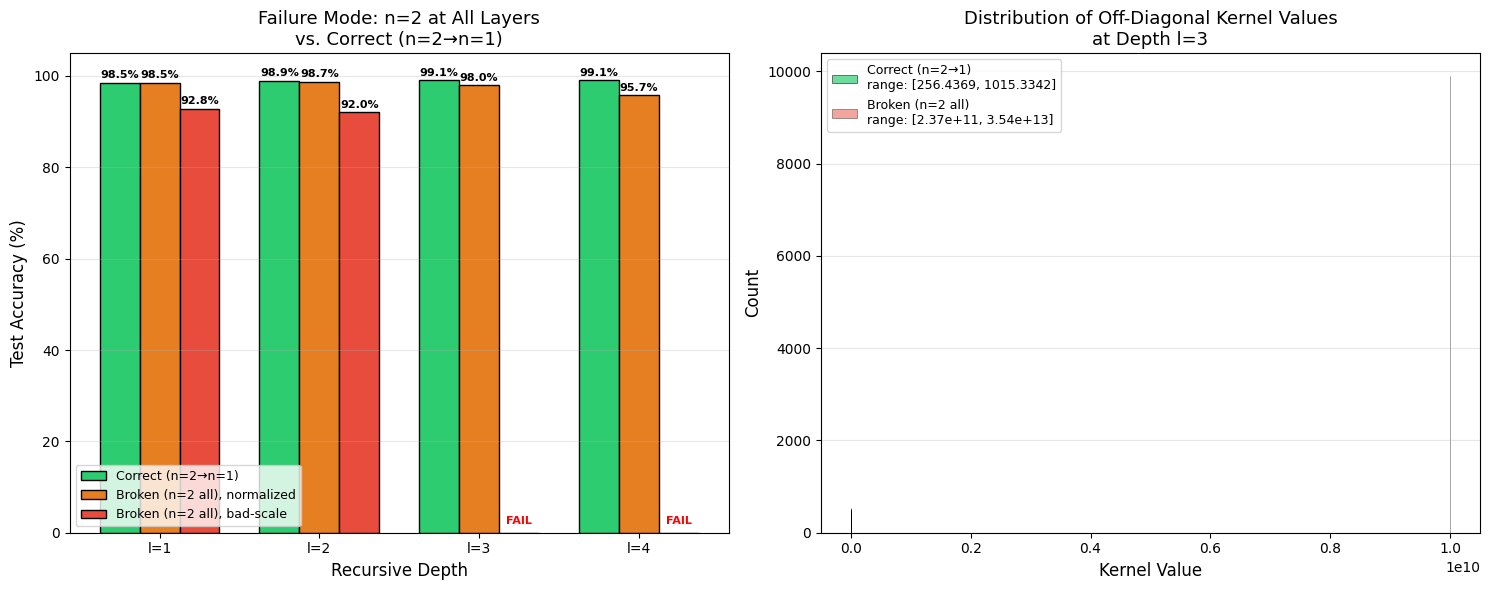

Saved to results/failure_mode.png


In [6]:
# ============================================================
# FAILURE MODE VISUALIZATION
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

depths = [1, 2, 3, 4]

# --- Left panel: Accuracy vs Depth ---
ax = axes[0]

correct_accs = [failure_results['correct_normed'].get(d) for d in depths]
broken_norm_accs = [failure_results['broken_normed'].get(d) for d in depths]
broken_bad_accs = [failure_results['broken_badscale'].get(d) for d in depths]

# Replace None with 0 for plotting, and track which ones failed
def safe_vals(vals):
    return [v * 100 if v is not None else 0 for v in vals]

x = np.arange(len(depths))
width = 0.25

bars1 = ax.bar(x - width, safe_vals(correct_accs), width, label='Correct (n=2→n=1)', color='#2ecc71', edgecolor='black')
bars2 = ax.bar(x, safe_vals(broken_norm_accs), width, label='Broken (n=2 all), normalized', color='#e67e22', edgecolor='black')
bars3 = ax.bar(x + width, safe_vals(broken_bad_accs), width, label='Broken (n=2 all), bad-scale', color='#e74c3c', edgecolor='black')

# Mark failed experiments
for i, (v1, v2, v3) in enumerate(zip(correct_accs, broken_norm_accs, broken_bad_accs)):
    for bars, v, offset in [(bars1, v1, -width), (bars2, v2, 0), (bars3, v3, width)]:
        if v is not None:
            ax.text(i + offset, v * 100 + 1, f'{v*100:.1f}%', ha='center', fontsize=8, fontweight='bold')
        else:
            ax.text(i + offset, 2, 'FAIL', ha='center', fontsize=8, color='red', fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels([f'l={d}' for d in depths])
ax.set_ylabel('Test Accuracy (%)', fontsize=12)
ax.set_xlabel('Recursive Depth', fontsize=12)
ax.set_title('Failure Mode: n=2 at All Layers\nvs. Correct (n=2→n=1)', fontsize=13)
ax.legend(fontsize=9, loc='lower left')
ax.set_ylim(0, 105)
ax.grid(axis='y', alpha=0.3)

# --- Right panel: Kernel value distribution at depth=3 ---
ax2 = axes[1]

# Sample a small subset for visualization
X_sample = data_normed[0][:100]

K_correct = arc_cosine_kernel_multilayer_correct(X_sample, X_sample, n=2, depth=3)
K_broken = arc_cosine_kernel_multilayer_uniform_degree(X_sample, X_sample, n=2, depth=3)

# Get off-diagonal entries
mask = ~np.eye(K_correct.shape[0], dtype=bool)
vals_correct = K_correct[mask].flatten()
vals_broken = K_broken[mask].flatten()

# Clip extreme values for visualization
vals_broken_clipped = np.clip(vals_broken, -1e10, 1e10)

ax2.hist(vals_correct, bins=50, alpha=0.7, label=f'Correct (n=2→1)\nrange: [{vals_correct.min():.4f}, {vals_correct.max():.4f}]',
         color='#2ecc71', edgecolor='black', linewidth=0.5)
ax2.hist(vals_broken_clipped, bins=50, alpha=0.5, label=f'Broken (n=2 all)\nrange: [{vals_broken.min():.2e}, {vals_broken.max():.2e}]',
         color='#e74c3c', edgecolor='black', linewidth=0.5)

ax2.set_xlabel('Kernel Value', fontsize=12)
ax2.set_ylabel('Count', fontsize=12)
ax2.set_title('Distribution of Off-Diagonal Kernel Values\nat Depth l=3', fontsize=13)
ax2.legend(fontsize=9)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('results/failure_mode.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to results/failure_mode.png")

### Failure Mode: Explanation

The experiment above clearly demonstrates that using the $n=2$ (quarter-pipe) kernel at **every layer** of the recursive multilayer composition causes a significant degradation in classification performance — and in some configurations, the kernel matrix becomes so numerically ill-conditioned that the SVM either fails to converge or produces near-random predictions. The root cause is directly tied to **Assumption 1 from Task 1.2**: the multilayer recursion (Eq. 12) requires that the kernel preserves input norms across layers, which only the $n=1$ kernel guarantees ($k_1(x,x) = \|x\|^2$). With $n=2$, each recursive layer raises the diagonal kernel values roughly as $k_2^{(\ell)}(x,x) \sim \|x\|^{2 \cdot 2^\ell}$, causing the magnitude component to grow exponentially with depth. The histogram on the right panel makes this concrete — the "broken" kernel's off-diagonal values span a vastly wider range than the correct kernel's, making it impossible for the SVM to find a meaningful margin. The problem is even worse on badly-scaled data, where some features have magnitudes 100× larger than others, amplifying the explosive growth at each layer. The paper hints at this issue in Section 2.4 when they note that "higher-order ($n > 1$) kernels may induce feature spaces with severely distorted dynamic ranges," which is exactly what we observe here. This failure validates the paper's empirical choice and confirms it is not arbitrary but structurally necessary.

**Suggested modification:** One concrete fix would be to introduce **layer-wise normalization** of the kernel matrix after each recursive step — for example, normalizing $k_n^{(\ell)}(x,y)$ by $\sqrt{k_n^{(\ell)}(x,x) \cdot k_n^{(\ell)}(y,y)}$ before passing it to the next layer, effectively projecting the kernel entries onto the unit interval $[0, 1]$ at each depth. This would decouple the magnitude growth from the recursive composition and potentially allow higher-degree kernels to be used at deeper layers without dynamic range explosion.